In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data_path = '../data/ProductsData'

In [2]:
categories = pd.read_csv('../data/csv/categories.csv')
customers = pd.read_csv('../data/csv/customers.csv')
employees = pd.read_csv('../data/csv/employees.csv')
orders = pd.read_csv('../data/csv/orders.csv')
order_details = pd.read_csv('../data/csv/orderDetails.csv')
products = pd.read_csv('../data/csv/products.csv')
suppliers = pd.read_csv('../data/csv/suppliers.csv')
shippers = pd.read_csv('../data/csv/shippers.csv')


shippers.columns

Index(['id', 'name', 'phone'], dtype='object')

In [3]:
df_products_order_details_categories = pd.read_csv('../data/csv/order_details_products_categories.csv')

order_details_with_products = pd.merge(order_details, products, left_on='product_id', right_on='id', suffixes=('_order_detail', '_product'))

order_details_with_products_and_categories = pd.merge(order_details_with_products, categories, left_on='category_id', right_on='id', suffixes=('', '_category'))

orders_with_customers = pd.merge(orders, customers, left_on='customer_id', right_on='id', suffixes=('', '_customer'))

orders_with_employees = pd.merge(orders_with_customers, employees, left_on='employee_id', right_on='employee_id', suffixes=('', '_employee'))

orders_with_shippers = pd.merge(orders_with_employees, shippers, left_on='shipper_id', right_on='id', suffixes=('', '_shipper'))

combined_df = pd.merge(order_details_with_products_and_categories, orders_with_shippers, left_on='order_id', right_on='id', suffixes=('', '_order'))

combined_df = pd.merge(combined_df, suppliers, left_on='supplier_id', right_on='id', suffixes=('', '_supplier'))

columns_to_drop = ['id_product', 'id_category', 'id_customer', 'id_employee', 'id_shipper', 'id_order']
combined_df = combined_df.drop(columns=columns_to_drop, errors='ignore')

print(combined_df.head())
combined_df.to_csv('../data/csv/combined_data.csv', index=False)
order_details_with_products_and_categories.to_csv('../data/csv/order_details_products_categories.csv', index=False)

   id_order_detail  order_id  product_id  quantity  \
0                1     10248          11        12   
1                2     10248          42        10   
2                3     10248          72         5   
3                4     10249          14         9   
4                5     10249          51        40   

                            name  supplier_id  category_id              unit  \
0                 Queso Cabrales            5            4         1 kg pkg.   
1  Singaporean Hokkien Fried Mee           20            5   32 - 1 kg pkgs.   
2         Mozzarella di Giovanni           14            4  24 - 200 g pkgs.   
3                           Tofu            6            7  40 - 100 g pkgs.   
4          Manjimup Dried Apples           24            7  50 - 300 g pkgs.   

   price  id  ...      name_shipper           phone  id_supplier  \
0  21.00   4  ...  Federal Shipping  (503) 555-9931            5   
1  14.00   5  ...  Federal Shipping  (503) 555-9931       

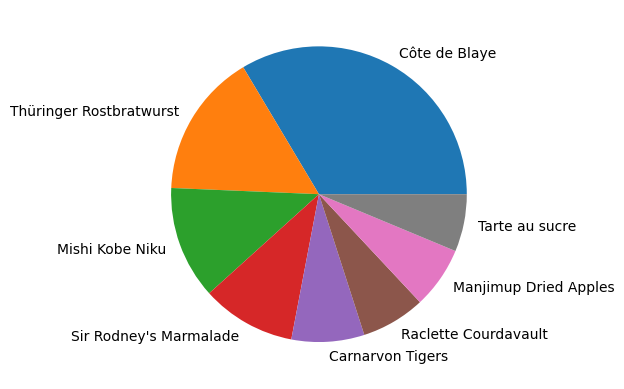

In [15]:
products_price = df_products_order_details_categories.groupby('name')['price'].unique().sort_values(ascending=False)[:8]
names = np.array(products_price.keys())
prices = np.array(products_price.values)

plt.pie(prices, labels=names)
plt.show()